## Avoiding rivers during the rainy season

The following code develops a routing function that helps avoid flooding events when routing withinn the Amazon rainforest. It considers river location, seasonality, and road networks.

At first, we develop the routing pipeline without integrating river info, and then weight to avoid rivers.

In [1]:
# load in necessary libraries
import os
import pandas as pd
import geopandas as gpd
from pyprojroot import here
import matplotlib.pyplot as plt
import networkx as nx
from math import radians, sin, cos, sqrt, atan2
from scipy.spatial import KDTree
import numpy as np

In [2]:
# read in data
osm_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-osm-paragominas.geojson")) # OSM roads
previsia_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-previsia-2025-paragominas.geojson")) # remotely-sensed roads
rivers = gpd.read_file(here("my-data/para/PA_1505502_RIOS_SIMPLES.shp")).set_crs("EPSG:31983").to_crs(osm_roads.crs) # river network
test = pd.read_csv(here("challenge-docs/challenge-3/test-pairs.csv")) # test pairs provided by hackathon

In [3]:
# same crs?
assert osm_roads.crs == previsia_roads.crs
assert rivers.crs == osm_roads.crs
osm_roads.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
# save test pairs as geo
test_pairs = test.assign( # iterate across appropriate columns and create points
    origin=list(zip(test.origin_lon, test.origin_lat)),
    dest=list(zip(test.dest_lon, test.dest_lat))
)

In [5]:
# filter for OSM roads that are accessible by vehicle
osm_roads_f = osm_roads[~osm_roads['highway'].isin(['track', 'path', 'footway', 'service'])]

#### Helper function: Haversine distance

In [6]:
# haversine distance function (as the crow flies)
def haversine(u, v):
    lon1, lat1 = u
    lon2, lat2 = v
    R = 6371000  # meters
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

### Routing pipeline

In [7]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())


#### Helper function: Snapping

In [8]:
nodes = list(G.nodes())
tree = KDTree(nodes)

def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist  # now returns distance too

In [9]:
results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

osm_results_df = pd.DataFrame(results)

# convert dest snap to meters
osm_results_df['dest_snap_m'] = osm_results_df['dest_snap_deg'] * 111000

osm_results_df

,id,path,road_distance_m,origin_snap_deg,dest_snap_deg,dest_snap_m
0,par-01,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",47046.634780,0.000214,0.023558,2614.905576
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",64585.638900,0.000214,0.028618,3176.622234
2,par-03,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",61375.744609,0.000214,0.031455,3491.463331
3,par-04,None,NaN,0.000214,0.050589,5615.349448
4,par-05,None,NaN,0.000214,0.050630,5619.894718
5,par-06,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",110433.783646,0.000214,0.022733,2523.345568
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",66855.786671,0.000214,0.028818,3198.852427
7,par-08,None,NaN,0.000214,0.054815,6084.453462
8,par-09,None,NaN,0.000214,0.055747,6187.959412
9,par-10,None,NaN,0.000214,0.050668,5624.107730


**Our metric for "reachable" will be 3km** – meaning workers will have to walk an additional 3km after reaching the point, by road, on a map. By this standard, _ of our points are currently reachable.


## Integrating rivers

<Axes: >

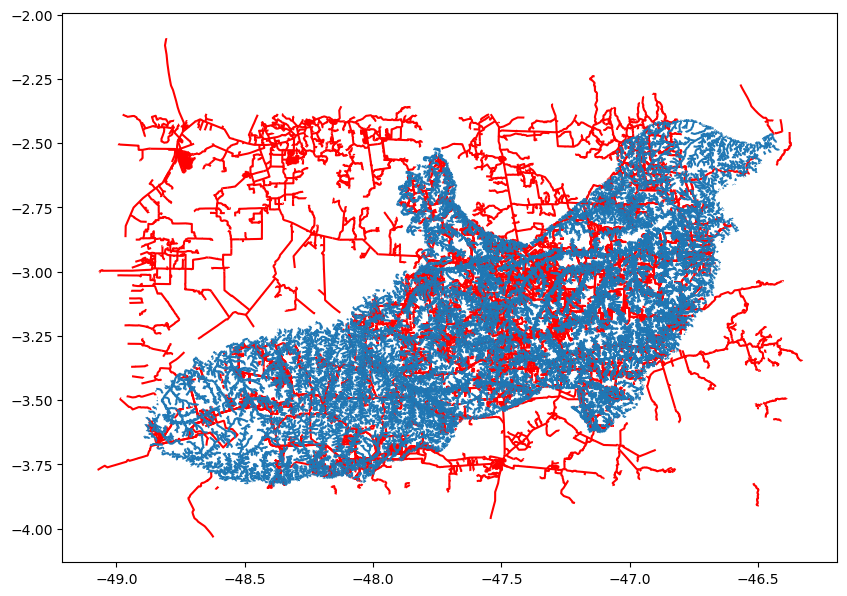

In [10]:
fig, ax = plt.subplots(figsize = (10, 10))
previsia_roads.plot(ax=ax,
                    color = 'red')
osm_roads.plot(ax=ax,
              color = "red")
rivers.plot(ax=ax)

In [11]:
# Find road segments that intersect any river
crossings = gpd.sjoin(osm_roads_f, rivers, predicate="intersects", how="inner")
print(len(crossings), "road segments cross a river")

1629 road segments cross a river


One of the few things we know about the OSM roads is their surface. We will assume that paved roads are safer than unpaved roads, when they cross rivers.

In [12]:
safe_surfaces = ['asphalt', 'paved', 'concrete']
risky_surfaces = ['unpaved', 'gravel', 'dirt', 'ground', 'sand', 'track']
unknown = crossings['surface'].isna()

crossings['risk'] = 'unknown'
crossings.loc[crossings['surface'].isin(safe_surfaces), 'risk'] = 'safe'
crossings.loc[crossings['surface'].isin(risky_surfaces), 'risk'] = 'risky'

In [13]:
# quantify penalty
penalty_map = {'safe': 1, 'unknown': 3, 'risky': 8}

### Apply surface and river penalty to 

In [14]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

nodes = list(G.nodes())
tree = KDTree(nodes)

def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist

# 1. Get the crossing point geometry for each crossing
crossings['crossing_point'] = crossings.apply(
    lambda row: row.geometry.intersection(rivers.loc[row.index_right].geometry),
    axis=1
)

# 2. Snap each crossing point to the nearest node in G
crossings['nearest_node'] = crossings['crossing_point'].apply(
    lambda pt: snap((pt.x, pt.y))[0] if pt.geom_type == 'Point' else None
)

# 3. Determine risk tier per crossing (from surface, as before)
penalty_map = {'safe': 1, 'unknown': 3, 'risky': 8}
crossings['penalty'] = crossings['risk'].map(penalty_map)

for u, v, data in G.edges(data=True):
    if 'base_weight' not in data:
        data['base_weight'] = data['weight']

for _, row in crossings.dropna(subset=['nearest_node']).iterrows():
    node = row['nearest_node']
    for neighbor in G.neighbors(node):
        G[node][neighbor]['weight'] = G[node][neighbor]['base_weight'] * row['penalty']


In [16]:
# --- BASELINE: no penalties ---
G_base = nx.Graph()
for _, row in osm_roads_f.iterrows():
    coords = list(row.geometry.coords)
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G_base.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

nodes_base = list(G_base.nodes())
tree_base = KDTree(nodes_base)
def snap_base(point):
    dist, idx = tree_base.query(point)
    return nodes_base[idx], dist

baseline_results = []
for _, row in test_pairs.iterrows():
    source, _ = snap_base(row.origin)
    target, _ = snap_base(row.dest)
    try:
        length = nx.shortest_path_length(G_base, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        length = None
    baseline_results.append({'id': row.id, 'baseline_distance_m': length})

baseline_df = pd.DataFrame(baseline_results)

# --- PENALIZED: G with river penalties already applied ---
penalized_results = []
for _, row in test_pairs.iterrows():
    source, _ = snap(row.origin)
    target, _ = snap(row.dest)
    try:
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        length = None
    penalized_results.append({'id': row.id, 'penalized_distance_m': length})

penalized_df = pd.DataFrame(penalized_results)

# --- COMPARE ---
comparison = baseline_df.merge(penalized_df, on='id')
comparison['diff_m'] = comparison['penalized_distance_m'] - comparison['baseline_distance_m']
comparison

,id,baseline_distance_m,penalized_distance_m,diff_m
0,par-01,47046.634780,47448.240416,401.605636
1,par-02,64585.638900,82613.807287,18028.168387
2,par-03,61375.744609,62064.103377,688.358768
3,par-04,NaN,NaN,NaN
4,par-05,NaN,NaN,NaN
5,par-06,110433.783646,152905.611188,42471.827541
6,par-07,66855.786671,85485.530206,18629.743535
7,par-08,NaN,NaN,NaN
8,par-09,NaN,NaN,NaN
9,par-10,NaN,NaN,NaN


## Integrating rivers, OSM, and PervesIA altogether

In [17]:
# build a graph like we did with the OSM roads
G_prev = nx.Graph()
for _, row in previsia_roads.iterrows():
    coords = list(row.geometry.coords)
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G_prev.add_edge(u, v, weight=haversine(u, v))

In [18]:
G_combined = nx.compose(G, G_prev)  # fresh rebuild, wipes old bad stitches

prev_components = list(nx.connected_components(G_prev))
osm_nodes = np.array(list(G.nodes()))
prev_nodes = np.array(list(G_prev.nodes()))
osm_tree = KDTree(osm_nodes)
tolerance_deg = 150 / 111000

for comp in prev_components:
    comp_arr = np.array(list(comp))
    dists, idxs = osm_tree.query(comp_arr)
    min_i = dists.argmin()
    if dists[min_i] < tolerance_deg:
        p_node = tuple(comp_arr[min_i])
        o_node = tuple(osm_nodes[idxs[min_i]])
        G_combined.add_edge(p_node, o_node, weight=dists[min_i] * 111000)

In [19]:
nodes = list(G_combined.nodes())
tree = KDTree(nodes)
def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist

comb_results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        penalized_length = nx.shortest_path_length(G_combined, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        penalized_length = None
    try:
        base_length = nx.shortest_path_length(G_combined, source=source, target=target, weight='base_weight')
    except nx.NetworkXNoPath:
        base_length = None
    comb_results.append({
        'id': row.id,
        'base_distance_m': base_length,
        'penalized_distance_m': penalized_length,
        'diff_m': (penalized_length - base_length) if (base_length is not None and penalized_length is not None) else None
    })

comb_df = pd.DataFrame(comb_results)
comb_df

,id,base_distance_m,penalized_distance_m,diff_m
0,par-01,43656.906382,45308.158251,1651.251869
1,par-02,67075.269306,92890.809377,25815.540071
2,par-03,NaN,NaN,NaN
3,par-04,NaN,NaN,NaN
4,par-05,NaN,NaN,NaN
5,par-06,NaN,NaN,NaN
6,par-07,NaN,NaN,NaN
7,par-08,NaN,NaN,NaN
8,par-09,NaN,NaN,NaN
9,par-10,NaN,NaN,NaN


It's possible that a lot of the fragmentation we find in the PrevisIA data is actually from rivers. With a sample size of two, we can't confirm or deny, but these results arent' a big shock.

## Incorporating seasonality and adding nuance

Wet and dry seasons change how risky a river crossing can be, so we will alter our weighting to account for this.

Flooding only occurs in north of Amazon, above equator ([WWF](https://wwf.panda.org/discover/knowledge_hub/where_we_work/amazon/about_the_amazon/ecosystems_amazon/floodplain_forests/)).

There is a lot of nuiance in Amazon weather, so it is recommendation that this operation gets split up based on subregions. For our small-scale example of Paragominas, we will be using information from [WeatherSpark](https://weatherspark.com/y/30245/Average-Weather-in-Paragominas-Par%C3%A1-Brazil-Year-Round).

In [22]:
def check_passability(month):

# built penalty weighting based on month of the year
    if month in ['January', 'February', 'May']:
        penalty_map = {'safe': 2, 'unknown': 4, 'risky': 9}
    elif month in ['March', 'April']:
        penalty_map = {'safe': 3, 'unknown': 5, 'risky': 10}
    else:
        penalty_map = {'safe': 1, 'unknown': 3, 'risky': 5}
    return penalty_map

In [24]:
def check_passability(month):

# built penalty weighting based on month of the year
    if month in ['January', 'February', 'May']:
        penalty_map = {'safe': 2, 'unknown': 4, 'risky': 9}
    elif month in ['March', 'April']:
        penalty_map = {'safe': 3, 'unknown': 5, 'risky': 10}
    else:
        penalty_map = {'safe': 1, 'unknown': 3, 'risky': 5}
    return penalty_map


In [ ]:
def route_for_month(G, crossings, test_pairs, month):
    nodes = list(G.nodes())
    tree = KDTree(nodes)
    def snap(point):
        dist, idx = tree.query(point)
        return nodes[idx], dist

    penalty_map = check_passability(month)
    crossings['penalty'] = crossings['risk'].map(penalty_map)

    for u, v, data in G.edges(data=True):
        if 'base_weight' not in data:
            data['base_weight'] = data['weight']

    for _, row in crossings.dropna(subset=['nearest_node']).iterrows():
        node = row['nearest_node']
        for neighbor in G.neighbors(node):
            G[node][neighbor]['weight'] = G[node][neighbor]['base_weight'] * row['penalty']

    results = []
    for _, row in test_pairs.iterrows():
        source, source_dist = snap(row.origin)
        target, target_dist = snap(row.dest)
        try:
            base_path = nx.shortest_path(G, source=source, target=target, weight='base_weight')
            base_length = nx.shortest_path_length(G, source=source, target=target, weight='base_weight')
        except nx.NetworkXNoPath:
            base_path, base_length = None, None
        try:
            penalized_path = nx.shortest_path(G, source=source, target=target, weight='weight')
            penalized_length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
        except nx.NetworkXNoPath:
            penalized_path, penalized_length = None, None
        results.append({
            'id': row.id,
            'month': month,
            'base_path': base_path,
            'base_distance_m': base_length,
            'penalized_path': penalized_path,
            'penalized_cost': penalized_length,
            'diff_m': (penalized_length - base_length) if (base_length is not None and penalized_length is not None) else None,
            'origin_snap_m': source_dist * 111000,
            'dest_snap_m': target_dist * 111000
        })

    return pd.DataFrame(results)

In [41]:
route_for_month(G, crossings, test_pairs, 'March')

,id,month,base_distance_m,penalized_distance_m,diff_m,origin_snap_m,dest_snap_m
0,par-01,March,47046.634780,70116.533254,23069.898473,23.736877,2614.905576
1,par-02,March,64585.638900,126616.681572,62031.042672,23.736877,3176.622234
2,par-03,March,61375.744609,88446.726330,27070.981721,23.736877,3491.463331
3,par-04,March,NaN,NaN,NaN,23.736877,5615.349448
4,par-05,March,NaN,NaN,NaN,23.736877,5619.894718
5,par-06,March,110433.783646,168171.791795,57738.008149,23.736877,2523.345568
6,par-07,March,66855.786671,109729.019602,42873.232930,23.736877,3198.852427
7,par-08,March,NaN,NaN,NaN,23.736877,6084.453462
8,par-09,March,NaN,NaN,NaN,23.736877,6187.959412
9,par-10,March,NaN,NaN,NaN,23.736877,5624.107730


In [39]:
route_for_month(G, crossings, test_pairs, 'December')

,id,month,base_distance_m,penalized_distance_m,diff_m
0,par-01,December,47046.634780,47398.124430,351.489650
1,par-02,December,64585.638900,82613.807287,18028.168387
2,par-03,December,61375.744609,62064.103377,688.358768
3,par-04,December,NaN,NaN,NaN
4,par-05,December,NaN,NaN,NaN
5,par-06,December,110433.783646,139056.815775,28623.032129
6,par-07,December,66855.786671,85485.530206,18629.743535
7,par-08,December,NaN,NaN,NaN
8,par-09,December,NaN,NaN,NaN
9,par-10,December,NaN,NaN,NaN


In [51]:
import matplotlib.pyplot as plt
from shapely.geometry import LineString

def plot_routes(row, osm_roads_f=None, padding=0.05):
    fig, ax = plt.subplots(figsize=(10, 10))

    if osm_roads_f is not None:
        osm_roads_f.plot(ax=ax, color='lightgray', linewidth=0.5, zorder=1)

    all_coords = []

    if row['base_path']:
        base_line = LineString(row['base_path'])
        gpd.GeoSeries([base_line]).plot(ax=ax, color='blue', linewidth=2, label='Baseline', zorder=2)
        all_coords.extend(row['base_path'])

    if row['penalized_path']:
        pen_line = LineString(row['penalized_path'])
        gpd.GeoSeries([pen_line]).plot(ax=ax, color='red', linewidth=2, linestyle='--', label='Penalized (safe)', zorder=3)
        all_coords.extend(row['penalized_path'])

    if all_coords:
        xs = [c[0] for c in all_coords]
        ys = [c[1] for c in all_coords]
        ax.set_xlim(min(xs) - padding, max(xs) + padding)
        ax.set_ylim(min(ys) - padding, max(ys) + padding)

    ax.legend()
    ax.set_title(f"{row['id']} — {row['month']}")
    plt.show()

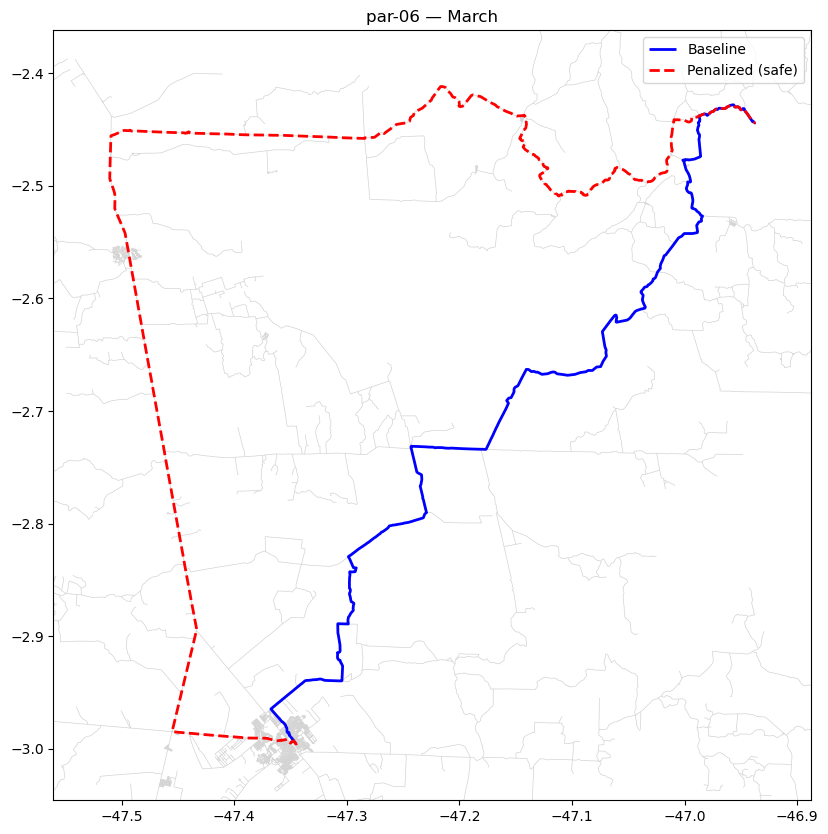

In [63]:
december_results = route_for_month(G, crossings, test_pairs, 'March')
row = december_results[december_results.id == 'par-06'].iloc[0]
plot_routes(row, osm_roads_f)

In [55]:
import networkx as nx

def path_length(G, path, weight):
    return sum(G[path[i]][path[i+1]][weight] for i in range(len(path)-1))

print(path_length(G, row['base_path'], 'base_weight'))
print(path_length(G, row['penalized_path'], 'weight'))

47046.63478032733
70116.53325365281
